# Filtrowanie Kolaboracyjne (Collaborative Filtering)
## Praca Magisterska: Porównanie algorytmów rekomendacyjnych

Pierwsza część pracy będzie opierała się na zbadaniu najstarszych i za razem najbardziej podstawowych systemów rekomendacyjnych; czyli filtrowania kolaboracyjnego. Technika ta przewiduje preferencje użytkownika na podstawie zachowań i ocen innych podobnych do niego użytkowników. W tym notebooku zbadano dwie szczególnie popularne techniki: 
- algorytm k-najbliższych sąsiadów
- model SVD (Singular Value Decomposition)

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dodanie folderu głównego do ścieżki, aby móc importować moduły z folderu Kod
sys.path.append(os.path.abspath(os.path.join('..')))

from Kod.Utils.data_loader import load_movielens_to_surprise
from Kod.Models.surprise_models import SurpriseSVDModel, SurpriseKNNModel
from surprise.model_selection import train_test_split
from surprise import accuracy

### 1. Ładowanie i Eksploracja Danych

In [2]:
# Wczytanie danych do ramki danych Pandas dla wstępnej analizy
df = pd.read_csv('../Kod/DataSource/data/movielens_100k.csv')

print(f"Liczba ocen: {len(df)}")
print(f"Liczba unikalnych użytkowników: {df['user_id'].nunique()}")
print(f"Liczba unikalnych filmów: {df['item_id'].nunique()}")

df.head()

Liczba ocen: 100000
Liczba unikalnych użytkowników: 943
Liczba unikalnych filmów: 1682


,user_id,item_id,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


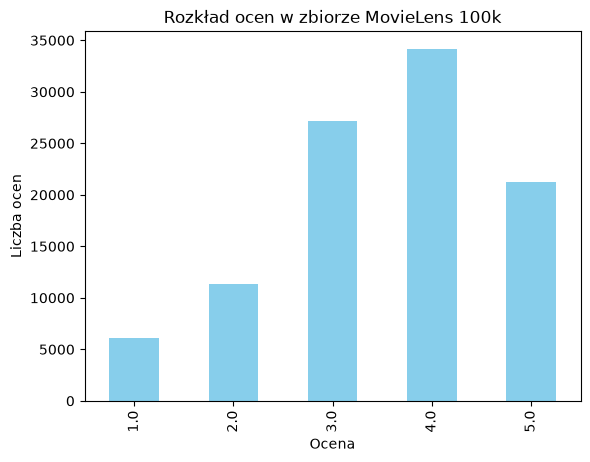

In [3]:
# Rozkład ocen
df['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Rozkład ocen w zbiorze MovieLens 100k')
plt.xlabel('Ocena')
plt.ylabel('Liczba ocen')
plt.show()

### 2. Przygotowanie danych do modelowania

In [5]:
# Ładowanie danych w formacie Surprise
data = load_movielens_to_surprise('../Data/movielens_100k.csv')

print(data)

# Podział na zbiór treningowy i testowy
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

### 3. Model KNN (K-Nearest Neighbors)
Metoda oparta na sąsiedztwie. Szukamy podobnych użytkowników (User-based) i na ich podstawie przewidujemy oceny.

In [6]:
knn_model = SurpriseKNNModel(k=40, sim_options={'name': 'cosine', 'user_based': True})
knn_model.train(trainset)

# Predykcje i ewaluacja
knn_predictions = knn_model.model.test(testset)
knn_rmse = accuracy.rmse(knn_predictions)
knn_mae = accuracy.mae(knn_predictions)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0194
MAE:  0.8038


### 4. Model SVD (Matrix Factorization)
Klasyczna metoda faktoryzacji macierzy, która była kluczowa w konkursie Netflix Prize.

In [7]:
svd_model = SurpriseSVDModel(n_factors=100, n_epochs=20)
svd_model.train(trainset)

# Predykcje i ewaluacja
svd_predictions = svd_model.model.test(testset)
svd_rmse = accuracy.rmse(svd_predictions)
svd_mae = accuracy.mae(svd_predictions)

RMSE: 0.9369
MAE:  0.7393


### 5. Porównanie wyników

In [8]:
results = pd.DataFrame({
    'Model': ['KNN (User-based)', 'SVD (Matrix Factorization)'],
    'RMSE': [knn_rmse, svd_rmse],
    'MAE': [knn_mae, svd_mae]
})

results

,Model,RMSE,MAE
0,KNN (User-based),1.019354,0.803799
1,SVD (Matrix Factorization),0.936899,0.739290
